In [1]:
import xarray as xr
import cmocean 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy
import cartopy.crs as ccrs
import cftime
import numpy as np

In [2]:
xr.set_options(display_style='html')
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 12,6

## Assessment of Geostrophic Balance
This dataset contains:
- sea surface height (SSH --> zos) (referenced to a global mean of zero)
- zonal (u --> uo) and meridional (v --> vo) velocities 
at daily temporal resolution.


Goal is to assess the accuracy of the geostrophic balance approximation:
- step: horizontal gradient estimation (dh/dx, dh/dy --> convert lat/lon to distance) 
- step: geostrophic velocity estimation (leverage the geostrophic balance relationship to find geostrophic velocities u_g, v_g)
- step: calculate difference between surface velocities (uo,vo) and surface geostrophic velocities (difference between u and u_g, v and v_g)


Questions to address/explore:
- question 1: consider and plot differences between u_g and uo, v_g and vo as a function of timescale (e.g. using a single time slice vs. a long time mean)
- question 2: how sensitive are results to the length scale over which a gradient is calculated? (remember velocities have to be averaged across the same length scale). Choose a second length scale to compute gradient and estimate velocity difference (think of center difference methods and/or linear slope fitting)
- question 3: compute relative vorticity at a single time slice and for the time mean

In [3]:
glorys_jan_mar_2021 = xr.open_zarr('../data/glorys_jan_mar_2021_daily_surface')

In [4]:
glorys_jan_mar_2021

<xarray.Dataset>
Dimensions:    (depth: 1, latitude: 385, longitude: 950, time: 90)
Coordinates:
  * depth      (depth) float32 0.494
  * latitude   (latitude) float32 19.25 19.33 19.42 19.5 ... 51.08 51.17 51.25
  * longitude  (longitude) float32 -87.25 -87.17 -87.08 ... -8.333 -8.25 -8.167
  * time       (time) datetime64[ns] 2021-01-01 2021-01-02 ... 2021-03-31
Data variables:
    so         (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    zos        (time, latitude, longitude) float32 dask.array<chunksize=(12, 97, 238), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.11
    comment:           CMEMS product
    history:           2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    institution:       MERCATOR OCEAN
    references:        http://www.mercator-ocean.fr
    source:            MERCATOR GLORYS12V1
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1D-m_202311
    subset:date:       2025-09-22T15:44:55.045Z
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    title:             daily mean fields from Global Ocean Physics Analysis a...

note: so is salinity, thetao is potential temperature

### Step 1: Horizontal Gradient

In [5]:
#this doesn't actually make sense to keep, but I spent a really long time on it, and it works, so she'll just be a docstring

def deltaxy(lat, lon):
    
    deltaxy = np.empty((len(lat)-2, len(lon)-2))
    for j in range(0, len(lat)-2):
        for i in range(0, len(lon)-2):
            lon2 = lon[i+2]
            lon0 = lon[i]
            lon2 = np.deg2rad(lon2)
            lon0 = np.deg2rad(lon0)
            dlon = lon2-lon0
            
            lat2 = lat[j+2]
            lat0 = lat[j]
            lat2 = np.deg2rad(lat2)
            lat0 = np.deg2rad(lat0)
            dlat = lat2-lat0

            a=np.sin(dlat/2.0)**2+np.cos(lat0)*np.cos(lat2)*np.sin(dlon/2)**2
            c=2*np.arcsin(np.sqrt(a))
            d=6378.137*c

            latmap=0.5*(lat[:-2]+lat[2:])
            lonmap=0.5*(lon[:-2]+lon[2:])
            
            deltaxy[j,i] = d

            deltaxy_mapped=xr.DataArray(deltaxy,dims=['latitude','longitude'],coords={'latitude':latmap,'longitude':lonmap})
            
    return deltaxy_mapped, deltaxy



In [6]:
def deltay(lat, lon):

    lat_ar = np.asarray(lat) #i had issues with this! #lets us set up the dataarray later
    lon_ar = np.asarray(lon)

    deltay = np.empty((len(lat_ar)-2, len(lon_ar)))
    for j in range(0, len(lat_ar)-2):
        lat2 = lat_ar[j+2]
        lat0 = lat_ar[j]
        lat2 = np.deg2rad(lat2)
        lat0 = np.deg2rad(lat0)
        dlat = lat2-lat0
        
        for i in range(0, len(lon_ar)):
            
            lon = lon_ar[i]
            lon = np.deg2rad(lon)
            
            a = np.sin(dlat / 2.0)**2
            c=2*np.arcsin(np.sqrt(a))
            d=6378.137*c
            
            deltay[j,i] = d

        mid_lat=lat_ar[1:-1]
            
    return xr.DataArray(data=deltay,coords={'latitude':mid_lat,'longitude':lon_ar},dims=['latitude','longitude'],name='dy')

In [7]:
def deltax(lat, lon):

    lat_ar = np.asarray(lat.values)
    lon_ar = np.asarray(lon.values)

    deltax = np.empty((len(lat_ar), len(lon_ar)-2))
    for j in range(0, len(lat_ar)):
        
        dlat = lat[j]
        dlat = np.deg2rad(dlat)
        
        for i in range(0, len(lon_ar)-2):
            
            lon2 = lon[i+2]
            lon0 = lon[i]
            lon2 = np.deg2rad(lon2)
            lon0 = np.deg2rad(lon0)
            dlon = lon2-lon0
            
            a = (np.cos(dlat)**2)*(np.sin(dlon/2.0)**2)
            c=2*np.arcsin(np.sqrt(a))
            d=6378.137*c
            
            deltax[j,i] = d

        mid_lon=lon_ar[1:-1]
            
    return xr.DataArray(data=deltax,coords={'latitude':lat_ar,'longitude':mid_lon},dims=['latitude','longitude'],name='dx')

In [8]:
#checking--deltay should be same ~19 km (https://www.nhc.noaa.gov/gccalc.shtml)
test_ds=glorys_jan_mar_2021.isel(longitude=slice(0,3)).isel(latitude=slice(0,3))
test_y=deltay(test_ds.latitude,test_ds.longitude)
test_y

<xarray.DataArray 'dy' (latitude: 1, longitude: 3)>
array([[18.55308002, 18.55308002, 18.55308002]])
Coordinates:
  * latitude   (latitude) float32 19.33
  * longitude  (longitude) float32 -87.25 -87.17 -87.08

In [9]:
#yay

In [10]:
#these should be ~17 km
test_x=deltax(test_ds.latitude,test_ds.longitude)
test_x

<xarray.DataArray 'dx' (latitude: 3, longitude: 1)>
array([[17.5155784 ],
       [17.50666466],
       [17.49771237]])
Coordinates:
  * latitude   (latitude) float32 19.25 19.33 19.42
  * longitude  (longitude) float32 -87.17

In [11]:
#yay

## Geostrophic Velocities

So! I have the functions to write dx and dy in km. I need to calculate dh, then divide dh by dx and dy.
I think it makes sense to first combine the output from the functions with the glorys dataset, so that I can reference the zos in a way that's connected to dx and dy. I think it also makes sense to extrapolate at the endpoints, so 1) there are less issues with combining everything, and 2) we aren't simply dropping a valid data point. 

### Step 2: Combining Datasets

In [12]:
glorys_dx=deltax(glorys_jan_mar_2021.latitude,glorys_jan_mar_2021.longitude)
glorys_dy=deltay(glorys_jan_mar_2021.latitude,glorys_jan_mar_2021.longitude)

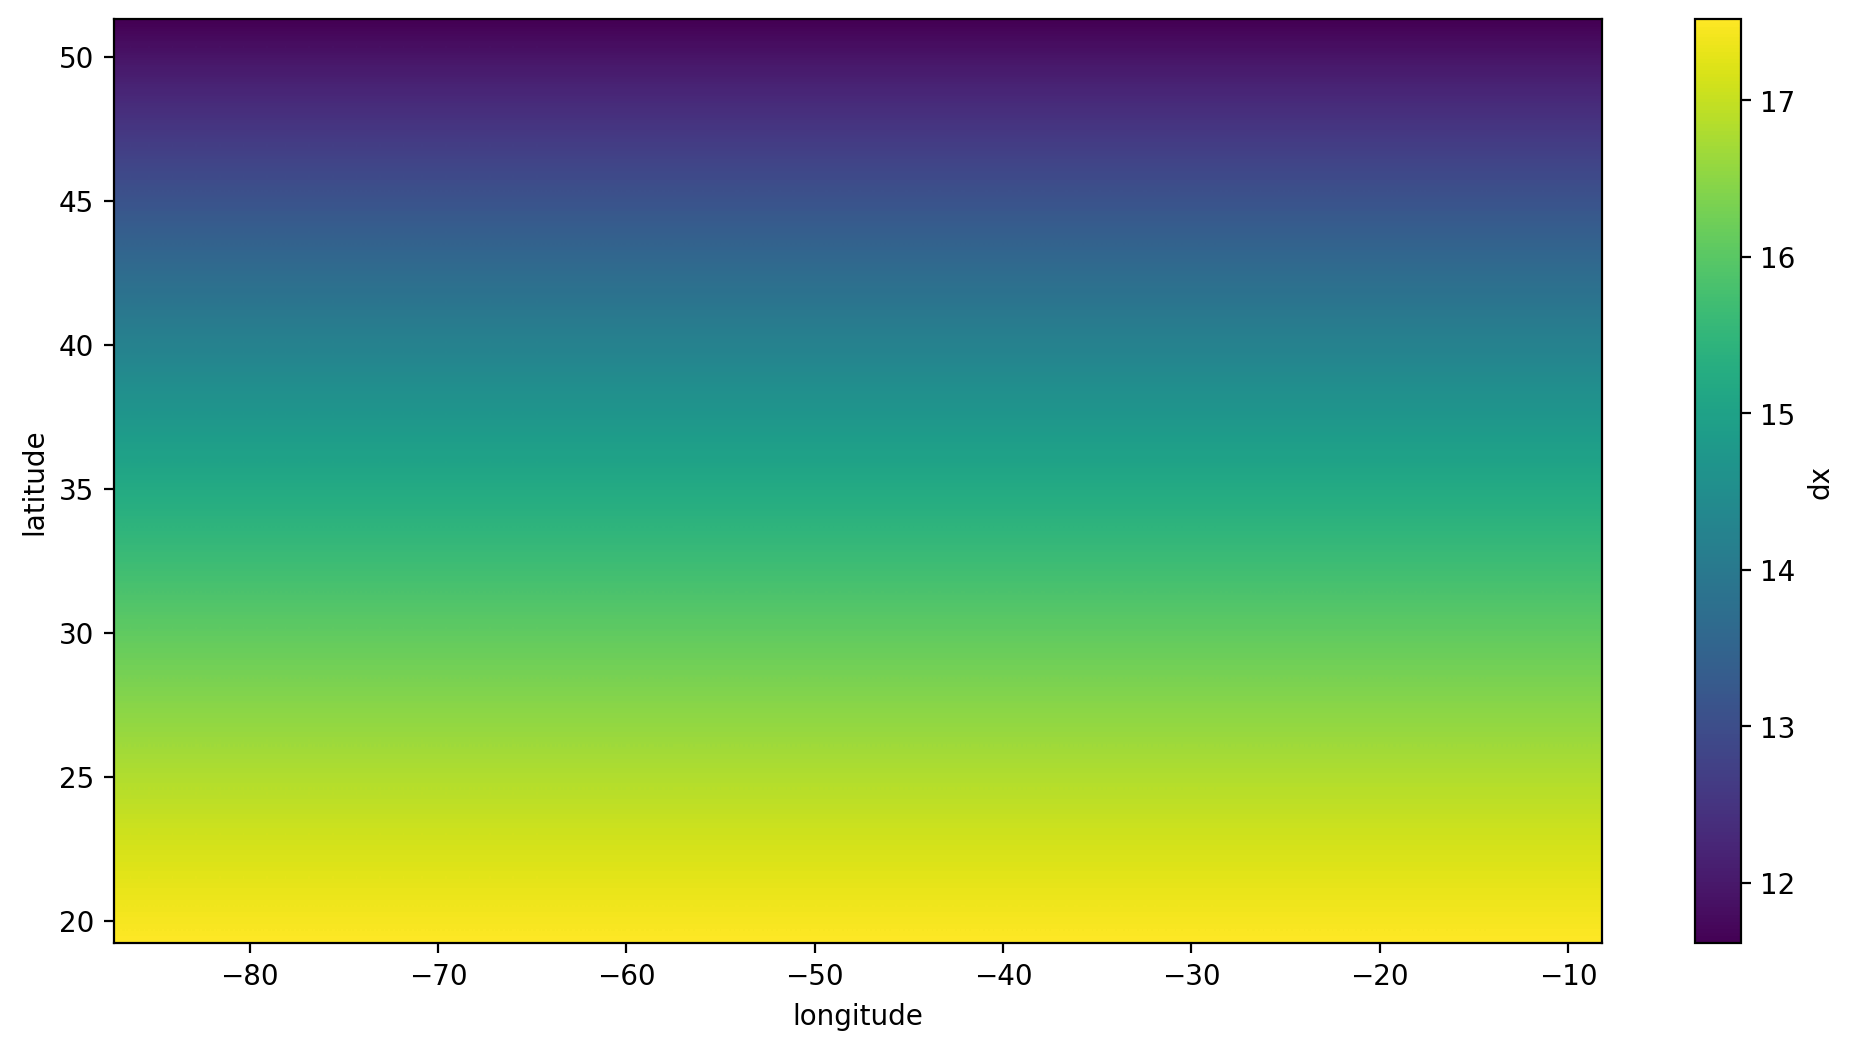

In [13]:
glorys_dx.plot() #linear

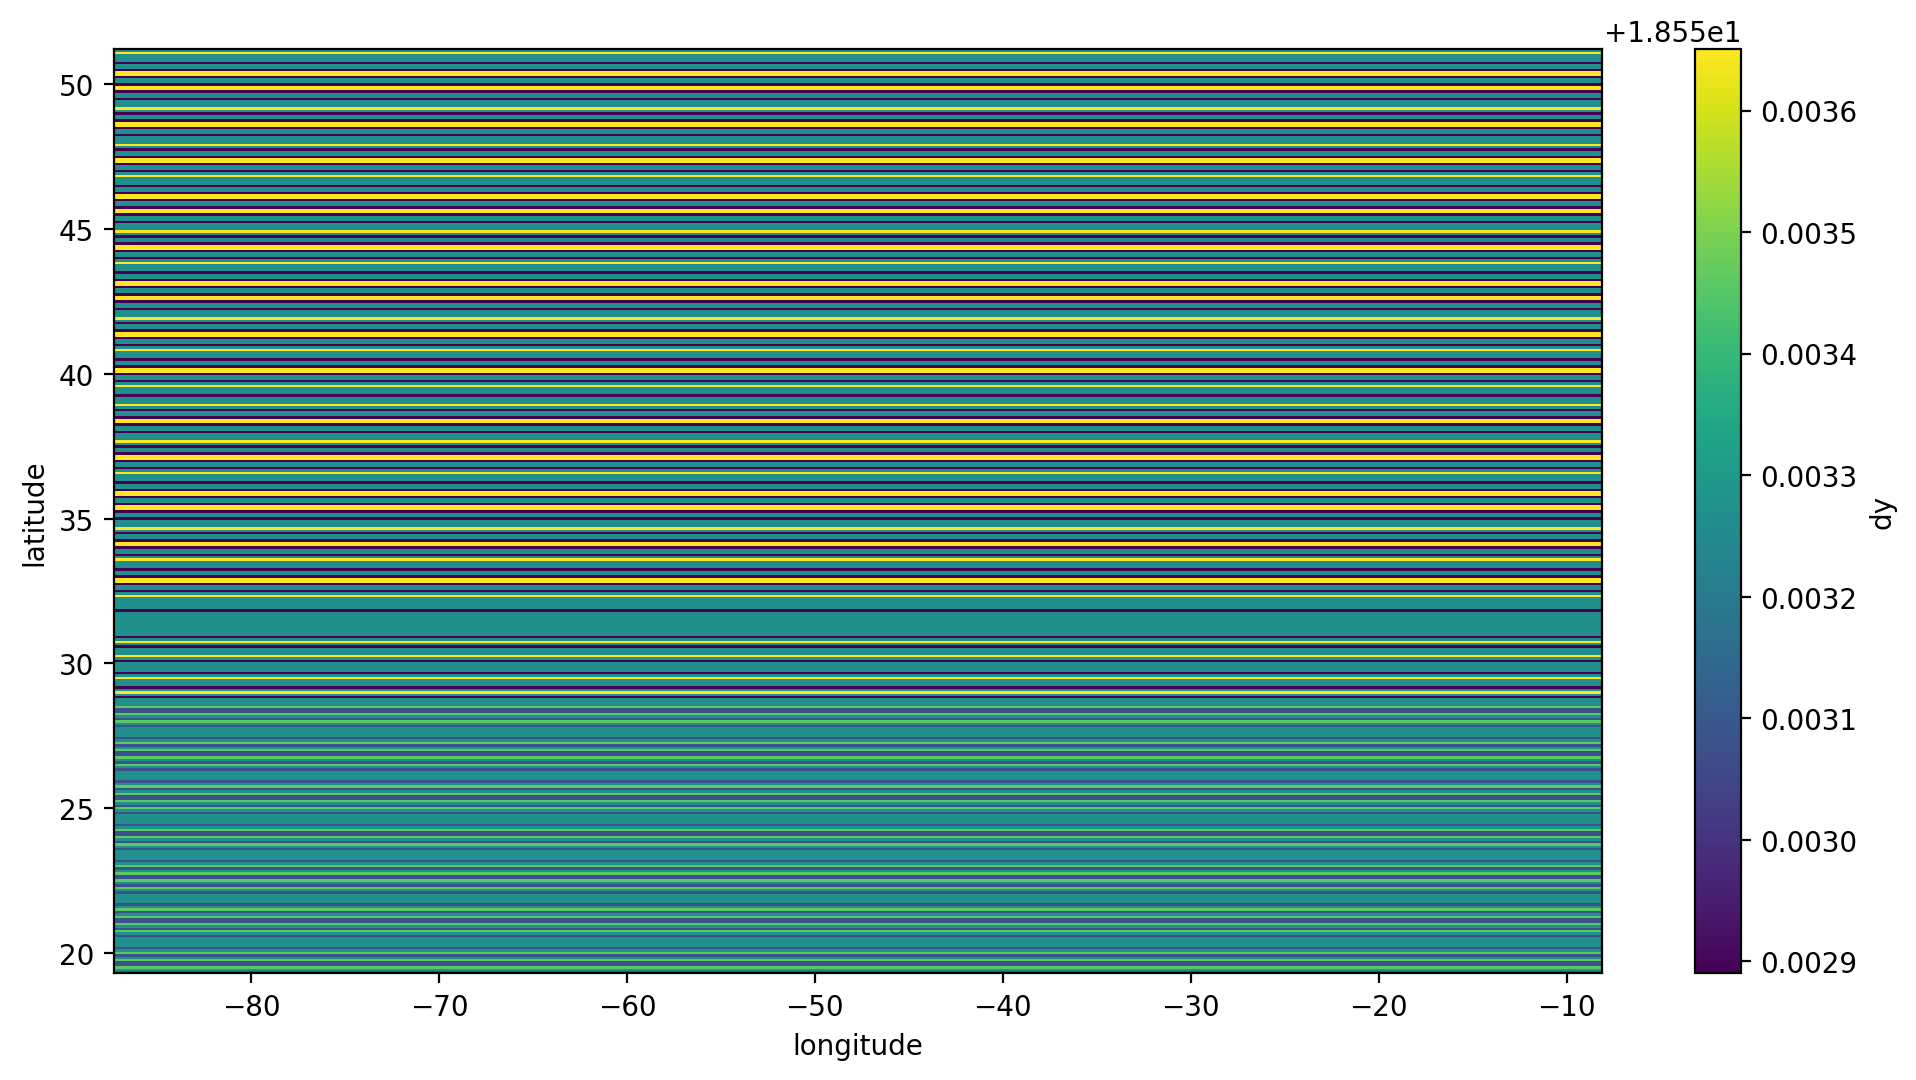

In [14]:
glorys_dy.plot() #this looks weird

Since the dx plot shows a linear relationship (dy is really special, it's fairly consistent but I'm curious about the differences that do appear), I'll use linear extrapolation. I think it's wise to use 3 points to do this to catch the bigger picture, while remaining true to the local patterns.

dx has truncated longitude --> need to extrapolate to -87.25 and -8.167

In [15]:
left_dlat_dx=glorys_dx.latitude[2]-glorys_dx.latitude[0] #x difference between last two
left_slope_dx=(glorys_dx[2]-glorys_dx[0])/left_dlat_dx #values over x difference --> slope
left_extrap_dx=glorys_dx[0]-left_slope_dx*left_dlat_dx #extrapolating


right_dlat_dx=glorys_dx.latitude[-1]-glorys_dx.latitude[-3] #x difference between last two
right_slope_dx=(glorys_dx[-1]-glorys_dx[-3])/right_dlat_dx #values over x difference --> slope
right_extrap_dx=glorys_dx[-1]-right_slope_dx*right_dlat_dx #extrapolating

This gives latitude 385 longitude 948. 

In [16]:

dx_lon_left=glorys_dx.longitude[1]-glorys_dx.longitude[0]
dx_lon_right=glorys_dx.longitude[-1]-glorys_dx.longitude[-2]
dx_lon=np.concatenate([[glorys_dx.longitude[0].values-dx_lon_left],glorys_dx.longitude[1:-1].values,[glorys_dx.longitude[-1].values+dx_lon_right]])

In [17]:
glorys_dx

<xarray.DataArray 'dx' (latitude: 385, longitude: 948)>
array([[17.5155784 , 17.51629622, 17.5155784 , ..., 17.51593731,
        17.51593731, 17.51593731],
       [17.50666466, 17.50738212, 17.50666466, ..., 17.50702339,
        17.50702339, 17.50702339],
       [17.49771237, 17.49842946, 17.49771237, ..., 17.49807092,
        17.49807092, 17.49807092],
       ...,
       [11.65472611, 11.65520374, 11.65472611, ..., 11.65496492,
        11.65496492, 11.65496492],
       [11.63371842, 11.63419519, 11.63371842, ..., 11.63395681,
        11.63395681, 11.63395681],
       [11.61268642, 11.61316233, 11.61268642, ..., 11.61292438,
        11.61292438, 11.61292438]])
Coordinates:
  * latitude   (latitude) float32 19.25 19.33 19.42 19.5 ... 51.08 51.17 51.25
  * longitude  (longitude) float32 -87.17 -87.08 -87.0 ... -8.417 -8.333 -8.25

In [18]:
glorys_dx.latitude

<xarray.DataArray 'latitude' (latitude: 385)>
array([19.25    , 19.333334, 19.416666, ..., 51.083332, 51.166668, 51.25    ],
      dtype=float32)
Coordinates:
  * latitude  (latitude) float32 19.25 19.33 19.42 19.5 ... 51.08 51.17 51.25

In [19]:
glorys_dy

<xarray.DataArray 'dy' (latitude: 383, longitude: 950)>
array([[18.55308002, 18.55308002, 18.55308002, ..., 18.55308002,
        18.55308002, 18.55308002],
       [18.5532701 , 18.5532701 , 18.5532701 , ..., 18.5532701 ,
        18.5532701 , 18.5532701 ],
       [18.55346019, 18.55346019, 18.55346019, ..., 18.55346019,
        18.55346019, 18.55346019],
       ...,
       [18.5532701 , 18.5532701 , 18.5532701 , ..., 18.5532701 ,
        18.5532701 , 18.5532701 ],
       [18.55365027, 18.55365027, 18.55365027, ..., 18.55365027,
        18.55365027, 18.55365027],
       [18.5532701 , 18.5532701 , 18.5532701 , ..., 18.5532701 ,
        18.5532701 , 18.5532701 ]])
Coordinates:
  * latitude   (latitude) float32 19.33 19.42 19.5 19.58 ... 51.0 51.08 51.17
  * longitude  (longitude) float32 -87.25 -87.17 -87.08 ... -8.333 -8.25 -8.167

In [20]:
glorys_dx.longitude

<xarray.DataArray 'longitude' (longitude: 948)>
array([-87.166664, -87.08333 , -86.99999 , ...,  -8.416656,  -8.333323,
        -8.24999 ], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -87.17 -87.08 -87.0 ... -8.417 -8.333 -8.25

In [21]:
glorys_dy.longitude

<xarray.DataArray 'longitude' (longitude: 950)>
array([-87.24999 , -87.166664, -87.08333 , ...,  -8.333323,  -8.24999 ,
        -8.166656], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -87.25 -87.17 -87.08 ... -8.333 -8.25 -8.167

---

In [22]:
glorys_jan_mar_2021.zos

<xarray.DataArray 'zos' (time: 90, latitude: 385, longitude: 950)>
dask.array<open_dataset-zos, shape=(90, 385, 950), dtype=float32, chunksize=(12, 97, 238), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 19.25 19.33 19.42 19.5 ... 51.08 51.17 51.25
  * longitude  (longitude) float32 -87.25 -87.17 -87.08 ... -8.333 -8.25 -8.167
  * time       (time) datetime64[ns] 2021-01-01 2021-01-02 ... 2021-03-31
Attributes:
    cell_methods:   area: mean
    long_name:      Sea surface height
    standard_name:  sea_surface_height_above_geoid
    unit_long:      Meters
    units:          m
    valid_max:      1.7346720695495605
    valid_min:      -1.9006928205490112

In [23]:
i=0
deltah=glorys_jan_mar_2021.zos.isel(latitude=(i+1))-glorys_jan_mar_2021.zos.isel(latitude=(i))
deltah

<xarray.DataArray 'zos' (time: 90, longitude: 950)>
dask.array<sub, shape=(90, 950), dtype=float32, chunksize=(12, 238), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 -87.25 -87.17 -87.08 ... -8.333 -8.25 -8.167
  * time       (time) datetime64[ns] 2021-01-01 2021-01-02 ... 2021-03-31

In [24]:
dhdx=deltah/dx
dhdy=deltah/dy

NameError: name 'dx' is not defined

In [ ]:
omega=#does change, we can approximate at first but really should be evaluated #1*10**-4  #7.2921*10**-5
g=9.80
dx=deltax(glorys_jan_mar_2021.latitude.values,glorys_jan_mar_2021.longitude.values)
dx_da=xr.DataArray(dx,dims=["latitude", "longitude"],coords={"latitude": glorys_jan_mar_2021['zos'].latitude, "longitude": glorys_jan_mar_2021['zos'].longitude})
dy=deltay(glorys_jan_mar_2021.latitude.values,glorys_jan_mar_2021.longitude.values)
dy_da=xr.DataArray(dy,dims=["latitude", "longitude"],coords={"latitude": glorys_jan_mar_2021['zos'].latitude, "longitude": glorys_jan_mar_2021['zos'].longitude})

f=2*omega*np.sin(np.deg2rad(glorys_jan_mar_2021['zos'].latitude))
f_array=xr.DataArray(f,dims=["latitude"],coords={"latitude":glorys_jan_mar_2021['zos'].latitude}) #this confused me a lot
#f_broadcast=f_array.broadcast_like(glorys_jan_mar_2021['zos'])    

def geostrophic_velocity(zos,latitude,longitude):
    for i in range(0, len(zos)):
        deltah=zos.isel(latitude=(i+1))-zos.isel(latitude=(i))#(zos.latitude[2:]-zos.latitude[:-2])
    #dhdx=deltah/dx
    #dhdy=deltah/dy
    #u=(-g/f)*dhdy
    #v=(g/f)*dhdx

   # return u, v
    return deltah

In [ ]:
omega=7.2921*10**-5
g=9.80
dx=deltax(glorys_jan_mar_2021.latitude.isel(latitude=slice(1,-1)).values,glorys_jan_mar_2021.longitude.isel(longitude=slice(1,-1)).values)
dx_da=xr.DataArray(dx,dims=["latitude", "longitude"],coords={"latitude": glorys_jan_mar_2021['zos'].latitude, "longitude": glorys_jan_mar_2021['zos'].longitude})
dy=deltay(glorys_jan_mar_2021.latitude.values,glorys_jan_mar_2021.longitude.values)
dy_da=xr.DataArray(dy,dims=["latitude", "longitude"],coords={"latitude": glorys_jan_mar_2021['zos'].latitude, "longitude": glorys_jan_mar_2021['zos'].longitude})

f=2*omega*np.sin(np.deg2rad(glorys_jan_mar_2021['zos'].latitude))
f_array=xr.DataArray(f,dims=["latitude"],coords={"latitude":glorys_jan_mar_2021['zos'].latitude}) #this confused me a lot

def geostrophic_velocity(zos,latitude,longitude):
    dhdx = (glorys_jan_mar_2021['zos'].isel(longitude=slice(2, None)) - glorys_jan_mar_2021['zos'].isel(longitude=slice(0, -2))) / dx_da.isel(longitude=slice(0, -2))
    dhdy = (glorys_jan_mar_2021['zos'].isel(latitude=slice(2, None)) - glorys_jan_mar_2021['zos'].isel(latitude=slice(0, -2))) / dy_da.isel(latitude=slice(0, -2))
    f_broadcast = f_da.isel(latitude=slice(1, -1)).broadcast_like(dhdy)
    u=(-g/f)*dhdy
    v=(g/f)*dhdx

    return u, v

In [ ]:
geostrophic_velocity(glorys_jan_mar_2021.zos.isel(latitude=slice(1,-1),longitude=slice(1,-1)),glorys_jan_mar_2021.latitude,glorys_jan_mar_2021.longitude)

## Jake

In [ ]:
zos = glorys_jan_mar_2021.zos.isel(time=20).load()

In [ ]:
f, ax = plt.subplots(1,1,figsize=(10,8),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(zos.longitude, zos.latitude, zos, vmin=-1, vmax=1, \
          cmap=plt.get_cmap('RdBu_r',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('SSH [m]')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

In [ ]:
# sample surface velocities
ss_u = glorys_jan_mar_2021.isel(time=20).uo.isel(depth=0).load()
ss_v = glorys_jan_mar_2021.isel(time=20).vo.isel(depth=0).load()
speed = 0.5*(ss_u**2 + ss_v**2)

In [ ]:
f, ax = plt.subplots(1,1,figsize=(10,8),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(ss_u.longitude, ss_u.latitude, speed, norm=LogNorm(vmin=0.01, vmax=1), \
          cmap=plt.get_cmap('viridis',10),transform=ccrs.PlateCarree())
ax.set_title(r'Surface Kinetic Energy [m$^2$s$^{-2}$]')
ax.set_facecolor('#cccccc')
axins1 = inset_axes(ax, width="30%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()